# M2 Deep Learning Coursework


**Name:** Baiyuan Chen

**CRSID:** bc654

*(Below, "we" is used instead of "I" to follow the convention of scientific writing.)*

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import json
import os

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Ensure output directories exist
os.makedirs("figs", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("logs", exist_ok=True)

## Question 1: A Mini Normalizing Flow

### 1(a) Affine Coupling Layer

We implement an affine coupling transform for a 2D vector $\mathbf{h} = [h_1, h_2]^\top$.

A single coupling layer keeps one component fixed and transforms the other:

$$h_1' = h_1, \qquad h_2' = h_2 \odot \exp(s(h_1)) + t(h_1)$$

where $s(\cdot)$ and $t(\cdot)$ are learned functions parameterised by a shared MLP:

$$\text{Linear}(D \to H) \to \text{ReLU} \to \text{Linear}(H \to 2D)$$

The output is split into $s$ and $t$, with $s \leftarrow \tanh(s)$ for numerical stability.

**Forward map** $f(\mathbf{z})$ (base $\to$ data): used for sampling.  
**Inverse map** $f^{-1}(\mathbf{x})$ (data $\to$ base): used for evaluating $\log p(\mathbf{x})$.

The log-determinant of the Jacobian for the forward direction is:

$$\log|\det J_f| = \sum_i s(h_1)_i$$

since the Jacobian is lower-triangular with diagonal entries $1$ (for the fixed component) and $\exp(s_i)$ (for the transformed components). For the inverse map, the log-det has the opposite sign.

In [2]:
class AffineCouplingLayer(nn.Module):
    """Affine coupling layer for even-dimensional data.

    When mask_first=True the first dim//2 components are kept fixed
    and the remaining components are transformed (and vice versa).
    """

    def __init__(self, dim: int = 2, hidden: int = 64, mask_first: bool = True):
        super().__init__()
        self.dim = dim
        self.mask_first = mask_first
        d_in = dim // 2
        d_out = dim - d_in
        self.net = nn.Sequential(
            nn.Linear(d_in, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 2 * d_out),
        )

    def _split(self, h):
        """Split input into (fixed, to_transform) parts."""
        d = self.dim // 2
        if self.mask_first:
            return h[..., :d], h[..., d:]
        else:
            return h[..., d:], h[..., :d]

    def _combine(self, fixed, transformed):
        """Recombine fixed and transformed parts."""
        if self.mask_first:
            return torch.cat([fixed, transformed], dim=-1)
        else:
            return torch.cat([transformed, fixed], dim=-1)

    def _get_s_t(self, fixed):
        """Compute scale s and translation t from the fixed components."""
        out = self.net(fixed)
        d_out = self.dim - self.dim // 2
        s, t = out[..., :d_out], out[..., d_out:]
        s = torch.tanh(s)
        return s, t

    def forward(self, z):
        """Forward map f(z): base -> data.

        Returns:
            x: transformed output
            log_det: log |det J_f| for each example in the batch
        """
        fixed, z_transform = self._split(z)
        s, t = self._get_s_t(fixed)
        x_transform = z_transform * torch.exp(s) + t
        log_det = s.sum(dim=-1)
        x = self._combine(fixed, x_transform)
        return x, log_det

    def inverse(self, x):
        """Inverse map f^{-1}(x): data -> base.

        Returns:
            z: transformed output
            log_det: log |det J_{f^{-1}}| for each example in the batch
        """
        fixed, x_transform = self._split(x)
        s, t = self._get_s_t(fixed)
        z_transform = (x_transform - t) * torch.exp(-s)
        log_det = -s.sum(dim=-1)
        z = self._combine(fixed, z_transform)
        return z, log_det

In [3]:
# Verify forward and inverse are consistent for a single layer
torch.manual_seed(SEED)
layer = AffineCouplingLayer(dim=2, hidden=64, mask_first=True)
z_test = torch.randn(5, 2)

x_out, logdet_fwd = layer.forward(z_test)
z_rec, logdet_inv = layer.inverse(x_out)

print("Max reconstruction error (single layer):", (z_test - z_rec).abs().max().item())
print("Log-det sum check (fwd + inv ~ 0):", (logdet_fwd + logdet_inv).abs().max().item())

Max reconstruction error (single layer): 1.1920928955078125e-07
Log-det sum check (fwd + inv ~ 0): 0.0


### 1(b) Normalizing Flow Model

We build a normalizing flow by stacking $K$ affine coupling layers with **alternating masks**: odd-indexed layers fix the first component and transform the second, while even-indexed layers do the reverse. This ensures both dimensions are transformed across the flow.

The base density is a standard normal $p(\mathbf{z}) = \mathcal{N}(\mathbf{0}, \mathbf{I})$.

To evaluate $\log p(\mathbf{x})$ we use the change-of-variables formula:

$$\log p(\mathbf{x}) = \log p(\mathbf{z}) + \log\left|\det \frac{\partial f^{-1}}{\partial \mathbf{x}}\right|$$

where $\mathbf{z} = f^{-1}(\mathbf{x})$ is obtained by passing $\mathbf{x}$ through the inverse of all $K$ layers in reverse order. The total log-determinant is the sum of the per-layer log-determinants.

In [4]:
class NormalizingFlow(nn.Module):
    """Normalizing flow built from K affine coupling layers with alternating masks."""

    def __init__(self, dim: int = 2, hidden: int = 64, n_layers: int = 8):
        super().__init__()
        self.dim = dim
        self.hidden = hidden
        self.n_layers = n_layers
        self.layers = nn.ModuleList()
        for i in range(n_layers):
            mask_first = (i % 2 == 0)
            self.layers.append(AffineCouplingLayer(dim=dim, hidden=hidden, mask_first=mask_first))

    def forward(self, z):
        """Forward map f(z): base -> data (sampling direction).

        Returns:
            x: transformed output
            log_det: total log |det J_f| for each example
        """
        log_det_total = torch.zeros(z.shape[0])
        x = z
        for layer in self.layers:
            x, log_det = layer.forward(x)
            log_det_total = log_det_total + log_det
        return x, log_det_total

    def inverse(self, x):
        """Inverse map f^{-1}(x): data -> base (density evaluation direction).

        Returns:
            z: transformed output
            log_det: total log |det J_{f^{-1}}| for each example
        """
        log_det_total = torch.zeros(x.shape[0])
        z = x
        for layer in reversed(self.layers):
            z, log_det = layer.inverse(z)
            log_det_total = log_det_total + log_det
        return z, log_det_total

    def log_prob(self, x):
        """Evaluate log p(x) for a batch of points.

        Uses change-of-variables: log p(x) = log p(z) + log |det J_{f^{-1}}|
        where z = f^{-1}(x) and p(z) = N(0, I).
        """
        z, log_det = self.inverse(x)
        # Base density: standard normal log p(z) = -0.5 * (d*log(2*pi) + ||z||^2)
        log_pz = -0.5 * (self.dim * np.log(2 * np.pi) + (z ** 2).sum(dim=-1))
        return log_pz + log_det

    def sample(self, n):
        """Draw n samples from the model by sampling z ~ N(0,I) and computing f(z)."""
        z = torch.randn(n, self.dim)
        x, _ = self.forward(z)
        return x

torch.manual_seed(SEED)
flow = NormalizingFlow(dim=2, hidden=64, n_layers=8)
z_test = torch.randn(5, 2)
x_out, logdet_fwd = flow.forward(z_test)
z_rec, logdet_inv = flow.inverse(x_out)
print("Max reconstruction error (full flow):", (z_test - z_rec).abs().max().item())
print("Log-det sum check (fwd + inv ~ 0):", (logdet_fwd + logdet_inv).abs().max().item())
print("log p(x) shape:", flow.log_prob(x_out).shape)

Max reconstruction error (full flow): 2.384185791015625e-07
Log-det sum check (fwd + inv ~ 0): 2.384185791015625e-07
log p(x) shape: torch.Size([5])


### 1(c) Correctness Checks

We verify the implementation with two checks:

1. **Invertibility check**: For every point $\mathbf{x}$ in the training set, compute $\mathbf{z} = f^{-1}(\mathbf{x})$, then reconstruct $\hat{\mathbf{x}} = f(\mathbf{z})$, and report $\max_i |\mathbf{x}_i - \hat{\mathbf{x}}_i|$.

2. **Log-determinant check**: For the first training example, numerically estimate the $2 \times 2$ Jacobian of $f^{-1}$ using central differences with $\varepsilon = 10^{-4}$:

$$J_{ij} \approx \frac{[f^{-1}(\mathbf{x} + \varepsilon \mathbf{e}_j)]_i - [f^{-1}(\mathbf{x} - \varepsilon \mathbf{e}_j)]_i}{2\varepsilon}$$

   Then compare $\log|\det J|$ to the analytic log-determinant returned by the inverse pass.

Results are saved to `results.json` and a two-panel diagnostic figure is saved to `figs/Figure1c.pdf`.

In [5]:
import csv

def load_moons_csv(path):
    """Load a moons CSV file and return a torch tensor of shape (N, 2)."""
    x1s, x2s = [], []
    with open(path) as f:
        reader = csv.DictReader(f)
        for row in reader:
            x1s.append(float(row["x1"]))
            x2s.append(float(row["x2"]))
    return torch.tensor(list(zip(x1s, x2s)), dtype=torch.float32)

train_data = load_moons_csv("data/moons_train.csv")
print("Training data shape:", train_data.shape)

# --- Check 1: Invertibility ---
flow.eval()
with torch.no_grad():
    z_inv, _ = flow.inverse(train_data)
    x_rec, _ = flow.forward(z_inv)
    recon_errors = (train_data - x_rec).abs()
    max_recon_error = recon_errors.max().item()

print(f"Invertibility max abs error: {max_recon_error:.2e}")

# --- Check 2: Log-det via finite differences ---
x0 = train_data[0:1]  # shape (1, 2)
eps = 1e-4
dim = 2

# Numerically estimate the Jacobian of f^{-1}
J_numerical = torch.zeros(dim, dim)
for j in range(dim):
    e_j = torch.zeros(1, dim)
    e_j[0, j] = eps
    with torch.no_grad():
        z_plus, _ = flow.inverse(x0 + e_j)
        z_minus, _ = flow.inverse(x0 - e_j)
    J_numerical[:, j] = (z_plus[0] - z_minus[0]) / (2 * eps)

log_det_numerical = torch.log(torch.abs(torch.det(J_numerical))).item()

# Analytic log-det from the inverse pass
with torch.no_grad():
    _, log_det_analytic_tensor = flow.inverse(x0)
log_det_analytic = log_det_analytic_tensor.item()

logdet_abs_error = abs(log_det_numerical - log_det_analytic)
print(f"Analytic log|det J_inv|:  {log_det_analytic:.6f}")
print(f"Numerical log|det J_inv|: {log_det_numerical:.6f}")
print(f"Log-det finite-diff abs error: {logdet_abs_error:.2e}")

Training data shape: torch.Size([800, 2])
Invertibility max abs error: 9.91e-07
Analytic log|det J_inv|:  0.466249
Numerical log|det J_inv|: 0.466059
Log-det finite-diff abs error: 1.90e-04


Saved correctness results to results.json


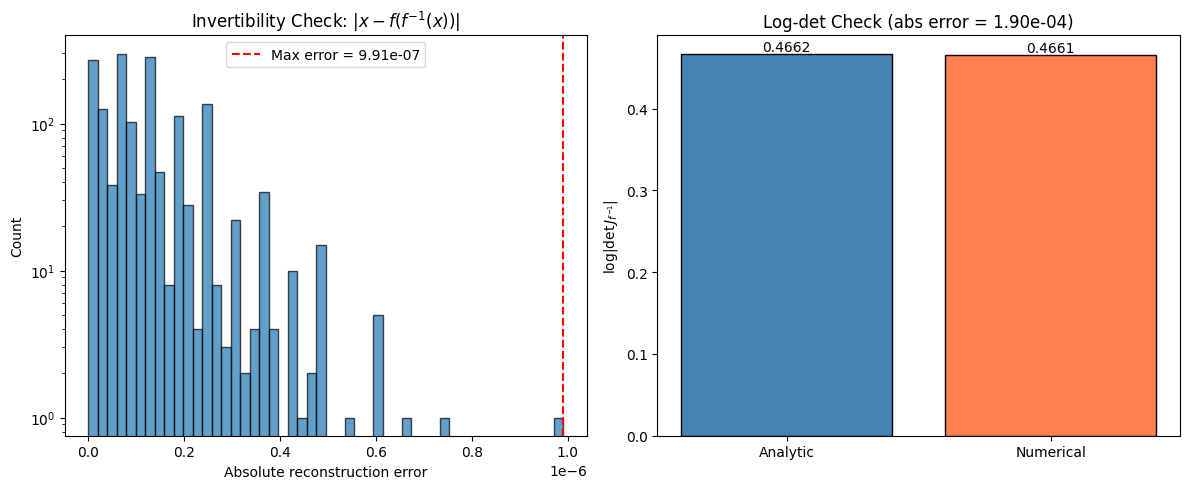

Saved figs/Figure1c.pdf


In [6]:
# --- Save to results.json ---
results = {}
try:
    with open("results.json") as f:
        content = f.read().strip()
        if content:
            results = json.loads(content)
except FileNotFoundError:
    pass

results["correctness"] = {
    "invertibility_max_abs_error": max_recon_error,
    "logdet_finite_diff_abs_error": logdet_abs_error,
}

with open("results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved correctness results to results.json")

# --- Two-panel diagnostic figure ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1: Invertibility — histogram of per-element reconstruction errors
all_errors = recon_errors.flatten().numpy()
axes[0].hist(all_errors, bins=50, edgecolor="black", alpha=0.7)
axes[0].axvline(max_recon_error, color="red", linestyle="--",
                label=f"Max error = {max_recon_error:.2e}")
axes[0].set_xlabel("Absolute reconstruction error")
axes[0].set_ylabel("Count")
axes[0].set_title("Invertibility Check: $|x - f(f^{-1}(x))|$")
axes[0].legend()
axes[0].set_yscale("log")

# Panel 2: Log-det check — bar chart comparing analytic vs numerical
bar_labels = ["Analytic", "Numerical"]
bar_values = [log_det_analytic, log_det_numerical]
bars = axes[1].bar(bar_labels, bar_values, color=["steelblue", "coral"], edgecolor="black")
axes[1].set_ylabel("$\\log|\\det J_{f^{-1}}|$")
axes[1].set_title(f"Log-det Check (abs error = {logdet_abs_error:.2e})")
for bar, val in zip(bars, bar_values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("figs/Figure1c.pdf", bbox_inches="tight")
plt.show()
print("Saved figs/Figure1c.pdf")

## Question 2: Training Pipeline

### 2(a) Tiny-Subset Training

As a sanity check before full training, we train on exactly the first 128 rows of `data/moons_train.csv`. The model should be able to overfit this small subset, driving the NLL down. This confirms the training loop and loss computation are correct before committing to a longer run.

In [7]:
# 2(a) Train on tiny subset (first 128 rows)
torch.manual_seed(SEED)
np.random.seed(SEED)

tiny_data = train_data[:128]
print("Tiny subset shape:", tiny_data.shape)

# Fresh model for tiny-subset training
flow_tiny = NormalizingFlow(dim=2, hidden=64, n_layers=8)
optimizer_tiny = torch.optim.Adam(flow_tiny.parameters(), lr=1e-4)

n_steps_tiny = 2000
tiny_losses = []

flow_tiny.train()
for step in range(n_steps_tiny):
    optimizer_tiny.zero_grad()
    log_px = flow_tiny.log_prob(tiny_data)
    loss = -log_px.mean()  # NLL
    loss.backward()
    optimizer_tiny.step()
    tiny_losses.append(loss.item())
    if (step + 1) % 500 == 0:
        print(f"Step {step+1}/{n_steps_tiny}, NLL: {loss.item():.4f}")

# Final tiny-set NLL
flow_tiny.eval()
with torch.no_grad():
    final_tiny_nll = -flow_tiny.log_prob(tiny_data).mean().item()
print(f"\nFinal tiny-set NLL: {final_tiny_nll:.4f}")

Tiny subset shape: torch.Size([128, 2])
Step 500/2000, NLL: 1.2103
Step 1000/2000, NLL: 0.5053
Step 1500/2000, NLL: 0.2931
Step 2000/2000, NLL: 0.1643

Final tiny-set NLL: 0.1641


Saved training.tinyset_final_nll to results.json


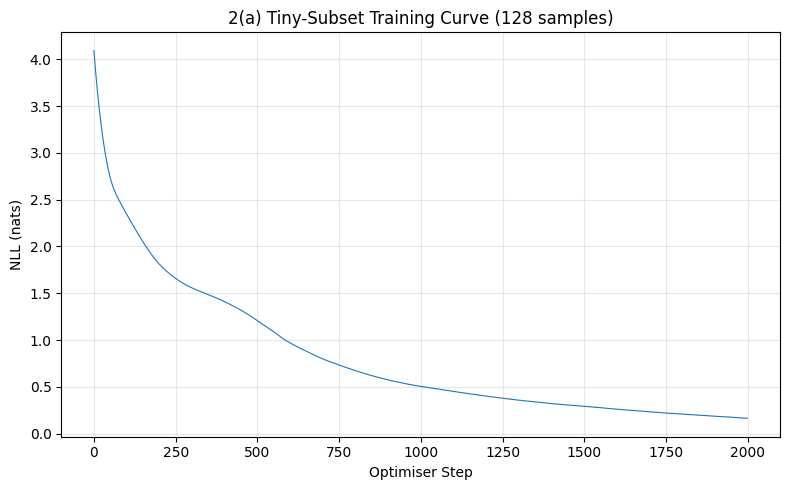

Saved figs/Figure2a.pdf


In [8]:
# Save to results.json
results = {}
try:
    with open("results.json") as f:
        content = f.read().strip()
        if content:
            results = json.loads(content)
except FileNotFoundError:
    pass

if "training" not in results:
    results["training"] = {}
results["training"]["tinyset_final_nll"] = final_tiny_nll

with open("results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved training.tinyset_final_nll to results.json")

# Plot and save loss curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tiny_losses, linewidth=0.8)
ax.set_xlabel("Optimiser Step")
ax.set_ylabel("NLL (nats)")
ax.set_title("2(a) Tiny-Subset Training Curve (128 samples)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figs/Figure2a.pdf", bbox_inches="tight")
plt.show()
print("Saved figs/Figure2a.pdf")

### 2(b) Full-Dataset Training

We now train on the full `data/moons_train.csv` (800 samples), evaluating on `data/moons_val.csv` periodically. The loss curves (train and validation) are saved to `figs/Figure2c.pdf`, and the final train, validation, and test NLLs are recorded in `results.json`.

Train: torch.Size([800, 2]), Val: torch.Size([100, 2]), Test: torch.Size([100, 2])
Step 1000/10000, Train NLL: 0.6491, Val NLL: 0.5911, LR: 0.000065
Step 2000/10000, Train NLL: 0.4882, Val NLL: 0.5290, LR: 0.000042
Step 3000/10000, Train NLL: 0.3922, Val NLL: 0.4988, LR: 0.000027
Step 4000/10000, Train NLL: 0.3127, Val NLL: 0.4304, LR: 0.000018
Step 5000/10000, Train NLL: 0.2756, Val NLL: 0.4049, LR: 0.000012
Step 6000/10000, Train NLL: 0.2577, Val NLL: 0.3979, LR: 0.000008
Step 7000/10000, Train NLL: 0.2465, Val NLL: 0.3968, LR: 0.000005
Step 8000/10000, Train NLL: 0.2395, Val NLL: 0.3955, LR: 0.000003
Step 9000/10000, Train NLL: 0.2351, Val NLL: 0.3936, LR: 0.000002
Step 10000/10000, Train NLL: 0.2323, Val NLL: 0.3929, LR: 0.000001

Final train NLL: 0.2323
Final val NLL:   0.3929
Final test NLL:  0.4440
Saved training results to results.json


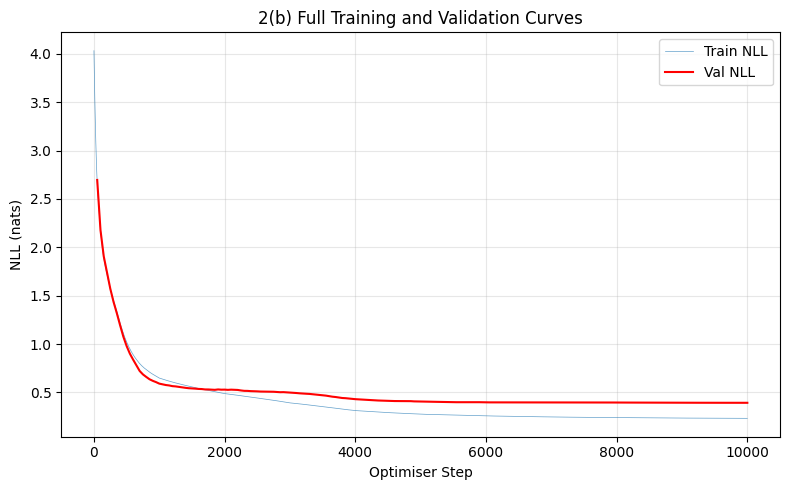

Saved figs/Figure2c.pdf


In [9]:
# 2(b) Full training on moons_train.csv
torch.manual_seed(SEED)
np.random.seed(SEED)

# Load val and test data
val_data = load_moons_csv("data/moons_val.csv")
test_data = load_moons_csv("data/moons_test.csv")
print(f"Train: {train_data.shape}, Val: {val_data.shape}, Test: {test_data.shape}")

# Model config
config = {"dim": 2, "hidden": 64, "n_layers": 8}
flow_full = NormalizingFlow(**config)
optimizer = torch.optim.Adam(flow_full.parameters(), lr=1e-4)

# Learning-rate schedule (see 2(c) description below)
n_steps_full = 10000
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=1000,
    gamma=0.65
)

full_losses = []
full_val_losses = []
eval_interval = 50  # evaluate val loss every 50 steps

flow_full.train()
for step in range(n_steps_full):
    optimizer.zero_grad()
    log_px = flow_full.log_prob(train_data)
    loss = -log_px.mean()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(flow_full.parameters(), max_norm=5.0)
    optimizer.step()
    scheduler.step()

    full_losses.append(loss.item())

    # Periodic validation
    if (step + 1) % eval_interval == 0:
        flow_full.eval()
        with torch.no_grad():
            val_loss = -flow_full.log_prob(val_data).mean().item()
        full_val_losses.append(val_loss)
        flow_full.train()

    if (step + 1) % 1000 == 0:
        print(f"Step {step+1}/{n_steps_full}, Train NLL: {loss.item():.4f}, "
              f"Val NLL: {full_val_losses[-1]:.4f}, LR: {scheduler.get_last_lr()[0]:.6f}")

# Final evaluation
flow_full.eval()
with torch.no_grad():
    final_train_nll = -flow_full.log_prob(train_data).mean().item()
    final_val_nll = -flow_full.log_prob(val_data).mean().item()
    final_test_nll = -flow_full.log_prob(test_data).mean().item()

print(f"\nFinal train NLL: {final_train_nll:.4f}")
print(f"Final val NLL:   {final_val_nll:.4f}")
print(f"Final test NLL:  {final_test_nll:.4f}")

# Update results.json with final NLLs
results = {}
try:
    with open("results.json") as f:
        content = f.read().strip()
        if content:
            results = json.loads(content)
except FileNotFoundError:
    pass

if "training" not in results:
    results["training"] = {}
results["training"]["final_train_nll"] = final_train_nll
results["training"]["final_val_nll"] = final_val_nll
results["training"]["final_test_nll"] = final_test_nll

with open("results.json", "w") as f:
    json.dump(results, f, indent=2)
print("Saved training results to results.json")

# Plot train and validation curves -> figs/Figure2c.pdf
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(full_losses, linewidth=0.5, alpha=0.7, label="Train NLL")
val_steps = [(i + 1) * eval_interval for i in range(len(full_val_losses))]
ax.plot(val_steps, full_val_losses, linewidth=1.5, label="Val NLL", color="red")
ax.set_xlabel("Optimiser Step")
ax.set_ylabel("NLL (nats)")
ax.set_title("2(b) Full Training and Validation Curves")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figs/Figure2c.pdf", bbox_inches="tight")
plt.show()
print("Saved figs/Figure2c.pdf")

### 2(c) Training Choices and Artifacts

The full training run above includes:

- **Learning-rate schedule**: `StepLR` with `step_size=1000` and `gamma=0.65`, reducing the learning rate by 35% every 1000 steps. This provides a simple, monotonic decay that helps the optimiser converge smoothly.
- **Gradient clipping**: `max_norm=5.0` to prevent occasional large gradient spikes from destabilising training (as observed in the tiny-subset run).
- **Full-batch training**: With only 800 samples and a small model, full-batch gradient descent is efficient and avoids stochastic noise.

We now save the required artifacts:
- `checkpoints/flow_full.pt` — checkpoint with keys `state_dict`, `config`, `seed`
- `logs/training_curves.json` — with keys `tiny_loss`, `full_loss`, `full_val_loss`

In [10]:
# 2(c) Save checkpoint and training curves

# Save final model checkpoint
torch.save({
    "state_dict": flow_full.state_dict(),
    "config": config,
    "seed": SEED,
}, "checkpoints/flow_full.pt")
print("Saved checkpoints/flow_full.pt")

# Save training curves log
training_curves = {
    "tiny_loss": tiny_losses,
    "full_loss": full_losses,
    "full_val_loss": full_val_losses,
}
with open("logs/training_curves.json", "w") as f:
    json.dump(training_curves, f)
print("Saved logs/training_curves.json")

Saved checkpoints/flow_full.pt
Saved logs/training_curves.json


## Question 3: Flow Surgery — A One-Parameter Family of Densities

### 3(a) Shear Map $g_\alpha$

We define an invertible shear map $g_\alpha : \mathbb{R}^2 \to \mathbb{R}^2$ by

$$\begin{pmatrix} y_1 \\ y_2 \end{pmatrix} = g_\alpha\!\begin{pmatrix} x_1 \\ x_2 \end{pmatrix} = \begin{pmatrix} x_1 + \alpha\, x_2 \\ x_2 \end{pmatrix}.$$

The Jacobian of $g_\alpha$ is
$$J_{g_\alpha} = \begin{pmatrix} 1 & \alpha \\ 0 & 1 \end{pmatrix}, \qquad \det J_{g_\alpha} = 1,$$
so the log-determinant is **zero** for every $\alpha$ and every input.

The inverse is
$$g_\alpha^{-1}\!\begin{pmatrix} y_1 \\ y_2 \end{pmatrix} = \begin{pmatrix} y_1 - \alpha\, y_2 \\ y_2 \end{pmatrix},$$
which also has unit Jacobian determinant.

In [11]:
def shear_forward(x, alpha):
    """Apply shear map g_alpha: y1 = x1 + alpha*x2, y2 = x2.

    Returns:
        y: transformed output
        log_det: log |det J_{g_alpha}| (always 0)
    """
    y = x.clone()
    y[..., 0] = x[..., 0] + alpha * x[..., 1]
    log_det = torch.zeros(x.shape[0])
    return y, log_det


def shear_inverse(y, alpha):
    """Apply inverse shear g_alpha^{-1}: x1 = y1 - alpha*y2, x2 = y2.

    Returns:
        x: transformed output
        log_det: log |det J_{g_alpha^{-1}}| (always 0)
    """
    x = y.clone()
    x[..., 0] = y[..., 0] - alpha * y[..., 1]
    log_det = torch.zeros(y.shape[0])
    return x, log_det


# --- Verify invertibility and log-det ---
torch.manual_seed(SEED)
x_test = torch.randn(5, 2)
for alpha in [-2, -1, 0, 1, 2]:
    y, ld_fwd = shear_forward(x_test, alpha)
    x_rec, ld_inv = shear_inverse(y, alpha)
    err = (x_test - x_rec).abs().max().item()
    print(f"alpha={alpha:+d}  recon err={err:.2e}  log_det_fwd={ld_fwd.sum().item():.1f}  log_det_inv={ld_inv.sum().item():.1f}")

alpha=-2  recon err=0.00e+00  log_det_fwd=0.0  log_det_inv=0.0
alpha=-1  recon err=0.00e+00  log_det_fwd=0.0  log_det_inv=0.0
alpha=+0  recon err=0.00e+00  log_det_fwd=0.0  log_det_inv=0.0
alpha=+1  recon err=2.98e-08  log_det_fwd=0.0  log_det_inv=0.0
alpha=+2  recon err=2.98e-08  log_det_fwd=0.0  log_det_inv=0.0


### 3(b) One-Parameter Family of Densities $p_\alpha(\mathbf{x})$

We load the trained flow $f_0$ from `checkpoints/flow_full.pt` and define a new sampling map

$$f_\alpha(\mathbf{z}) = g_\alpha\!\bigl(f_0(\mathbf{z})\bigr),$$

which composes the trained flow with the shear map from 3(a). Since $g_\alpha$ is volume-preserving ($\log|\det J_{g_\alpha}| = 0$), the induced density under $f_\alpha$ is

$$\log p_\alpha(\mathbf{x}) = \log p_0\!\bigl(g_\alpha^{-1}(\mathbf{x})\bigr),$$

i.e. we simply evaluate the original model's log-density at the *un-sheared* point. No retraining is needed.

We generate 1000 samples for each $\alpha \in \{-2, -1, 0, 1, 2\}$ and display them in a five-panel figure saved to `figs/Figure3b.pdf`.

Loaded flow from checkpoints/flow_full.pt
Config: {'dim': 2, 'hidden': 64, 'n_layers': 8}


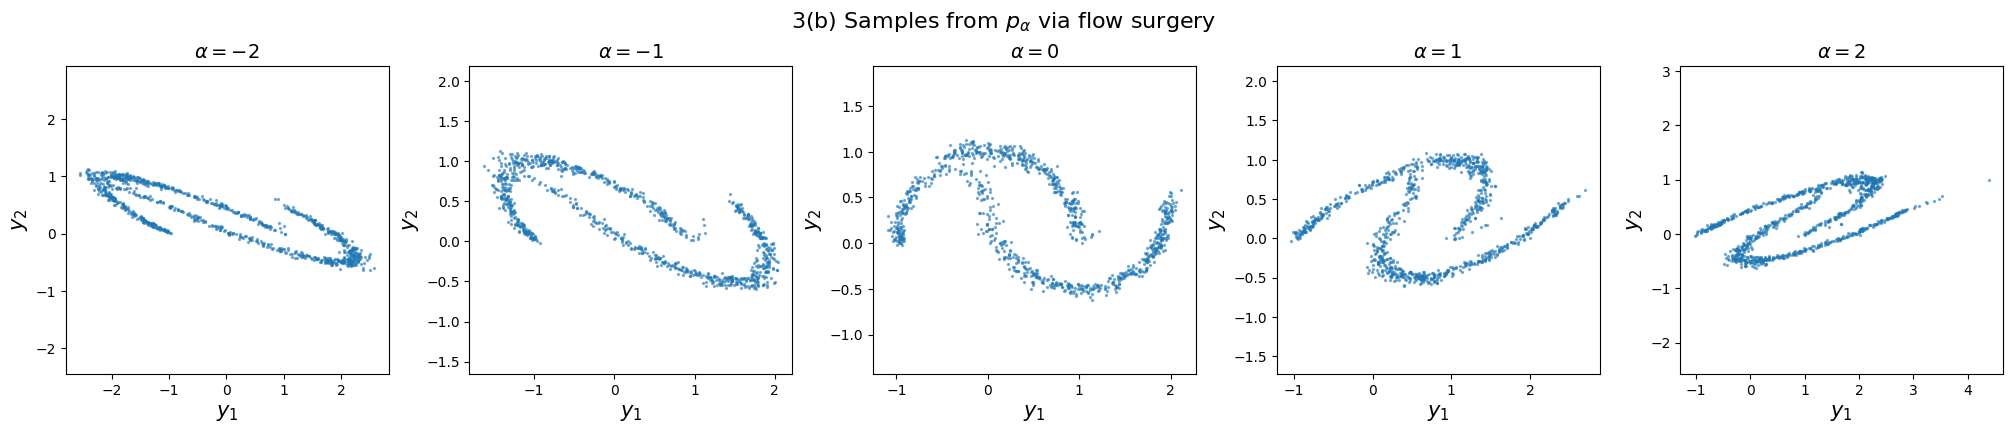

Saved figs/Figure3b.pdf


In [12]:
# Load checkpoint
ckpt = torch.load("checkpoints/flow_full.pt", weights_only=False)
flow_surgery = NormalizingFlow(**ckpt["config"])
flow_surgery.load_state_dict(ckpt["state_dict"])
flow_surgery.eval()
print("Loaded flow from checkpoints/flow_full.pt")
print("Config:", ckpt["config"])

# Sample and shear
alphas = [-2, -1, 0, 1, 2]
n_samples = 1000
torch.manual_seed(SEED)

fig, axes = plt.subplots(1, 5, figsize=(25, 4))

for ax, alpha in zip(axes, alphas):
    with torch.no_grad():
        # Sample from base, push through trained flow, then apply shear
        z = torch.randn(n_samples, 2)
        x, _ = flow_surgery.forward(z)
        y, _ = shear_forward(x, alpha)

    y_np = y.numpy()
    ax.scatter(y_np[:, 0], y_np[:, 1], s=2, alpha=0.5)
    ax.set_title(f"$\\alpha = {alpha}$", fontsize=14)
    ax.set_xlabel("$y_1$", fontsize=15)
    ax.set_ylabel("$y_2$", fontsize=15)
    ax.set_aspect("equal", adjustable="datalim")

fig.suptitle("3(b) Samples from $p_\\alpha$ via flow surgery", fontsize=16, y=1.02)
plt.subplots_adjust(wspace=0.25)
plt.savefig("figs/Figure3b.pdf", bbox_inches="tight")
plt.show()
print("Saved figs/Figure3b.pdf")

## Question 4: FLOP Counting Function

### 4(a) Deriving the FLOP Count

We count the FLOPs required to evaluate $\log p(\mathbf{x})$ for a batch of $B$ examples with our normalizing flow of $K$ coupling layers, data dimension $D$ (even), and MLP hidden width $H$.

The evaluation performs the **inverse pass** through all $K$ layers, accumulates the log-determinant, then evaluates the base density.

**Notation.** The spec describes the MLP as "Linear$(D \to H) \to$ ReLU $\to$ Linear$(H \to 2D)$" applied to the **masked input**. The masked input has $d_{\mathrm{in}} = D/2$ components (the fixed half), and the output $2D$ has $2 \cdot d_{\mathrm{in}} = D$ elements, split into $s$ and $t$ each of size $d_{\mathrm{out}} = D/2$. Here $D$ in the architecture description refers to the MLP input dimension $d_{\mathrm{in}} = \texttt{dim}/2$, since the MLP only receives the fixed components.

---

**Per coupling layer (inverse direction), per example:**

| Operation | FLOPs |
|---|---|
| `Linear(d_in → H)` with bias: $H$ outputs, each $2 \, d_{\mathrm{in}}$ FLOPs | $2 \, d_{\mathrm{in}} \, H$ |
| `ReLU` on $H$ units | $H$ |
| `Linear(H → 2·d_out)` with bias: $2\,d_{\mathrm{out}}$ outputs, each $2H$ FLOPs | $4 \, d_{\mathrm{out}} \, H$ |
| $s \leftarrow \tanh(s)$ on $d_{\mathrm{out}}$ elements | $10 \, d_{\mathrm{out}}$ |
| Negate $s$ (for $\exp(-s)$) | $d_{\mathrm{out}}$ |
| $\exp(-s)$ on $d_{\mathrm{out}}$ elements | $10 \, d_{\mathrm{out}}$ |
| Subtract $t$: $(x_{\mathrm{tr}} - t)$ | $d_{\mathrm{out}}$ |
| Multiply: $(x_{\mathrm{tr}} - t) \odot \exp(-s)$ | $d_{\mathrm{out}}$ |
| Negate $s$ for log-det (no reuse assumed) | $d_{\mathrm{out}}$ |
| Sum $d_{\mathrm{out}}$ negated values | $d_{\mathrm{out}} - 1$ |
| Accumulate log-det into running total | $1$ |

Collecting constant terms: $10 + 1 + 10 + 1 + 1 + 1 + 1 = 25$ per $d_{\mathrm{out}}$ element (the $-1$ and $+1$ from sum/accumulate cancel). So:

$$C_{\mathrm{layer}} = 2 \, d_{\mathrm{in}} \, H + H + 4 \, d_{\mathrm{out}} \, H + 25 \, d_{\mathrm{out}}$$

---

**After all $K$ layers:**

| Operation | FLOPs |
|---|---|
| Base-density evaluation ($B$ examples) | $20\,B$ |
| Final addition $\log p(\mathbf{z}) + \log|\det|$ | $B$ |

**Grand total:**

$$\boxed{\mathrm{FLOPs} = K \cdot B \cdot \bigl(2 \, d_{\mathrm{in}} \, H + H + 4 \, d_{\mathrm{out}} \, H + 25 \, d_{\mathrm{out}}\bigr) + 21\,B}$$

where $d_{\mathrm{in}} = \lfloor D/2 \rfloor$ and $d_{\mathrm{out}} = D - d_{\mathrm{in}}$.

**Simplifying assumptions:**
- Each `Linear(in, out)` with bias costs $2 \cdot \mathrm{in} \cdot \mathrm{out}$ FLOPs per example (one multiply + one add per weight, bias absorbed).
- Intermediate $-s$ is **not** reused between transform and log-det; each negation counted separately.
- Indexing, splitting, and concatenation are free.
- Base-density evaluation is a flat 20 FLOPs per example as specified.


In [13]:
# 4(b) FLOP counting function

def count_flops(*, dim: int, n_layers: int, hidden: int, batch_size: int) -> int:
    """Count FLOPs for evaluating log p(x) on a batch.

    The MLP in each coupling layer is Linear(d_in -> H) -> ReLU -> Linear(H -> 2*d_out)
    where d_in = dim // 2 (fixed components) and d_out = dim - dim // 2 (transformed).
    The MLP is applied to the masked input (d_in components), producing s and t
    each of size d_out.

    Assumptions:
      - Linear(in, out) with bias costs 2*in*out FLOPs per example
      - No reuse of -s between transform and log-det
      - Base density: 20 FLOPs/example (as specified)
      - Indexing/splitting/concatenation are free
    """
    d_in = dim // 2
    d_out = dim - d_in
    H = hidden
    K = n_layers
    B = batch_size

    # Per coupling layer, per example:
    #   Linear(d_in -> H):         2 * d_in * H
    #   ReLU(H):                   H
    #   Linear(H -> 2*d_out):      4 * d_out * H
    #   tanh(s) on d_out:          10 * d_out
    #   negate s (for exp):        d_out
    #   exp(-s):                   10 * d_out
    #   subtract t:                d_out
    #   multiply:                  d_out
    #   negate s (for logdet):     d_out    (no reuse)
    #   sum d_out values:          d_out - 1
    #   accumulate logdet:         1
    #   => constant terms = 25 * d_out
    flops_per_layer = (
        2 * d_in * H       # Linear 1
        + H                 # ReLU
        + 4 * d_out * H    # Linear 2
        + 25 * d_out        # tanh + inverse transform + logdet
    )

    # Total = K layers * B examples * per-layer cost + base density (20B) + final add (B)
    total = K * B * flops_per_layer + 21 * B

    return total


# --- Verify with concrete values ---
print("=== FLOP counts ===")
D, H, K = 2, 64, 8
d_in = D // 2
d_out = D - d_in
c_layer = 2*d_in*H + H + 4*d_out*H + 25*d_out
print(f"dim={D}, hidden={H}, n_layers={K}:")
print(f"  d_in={d_in}, d_out={d_out}")
print(f"  Linear1: {2*d_in*H}, ReLU: {H}, Linear2: {4*d_out*H}, ops: {25*d_out}")
print(f"  C_layer = {c_layer}")
print(f"  Total (B=1):   {count_flops(dim=D, n_layers=K, hidden=H, batch_size=1)}")
print(f"  Total (B=800): {count_flops(dim=D, n_layers=K, hidden=H, batch_size=800)}")

# Generality check with dim=4
D4 = 4
d_in4 = D4 // 2
d_out4 = D4 - d_in4
c4 = 2*d_in4*H + H + 4*d_out4*H + 25*d_out4
print(f"\ndim={D4}: d_in={d_in4}, d_out={d_out4}, C_layer={c4}")
print(f"  Total (B=1): {count_flops(dim=D4, n_layers=K, hidden=H, batch_size=1)}")


=== FLOP counts ===
dim=2, hidden=64, n_layers=8:
  d_in=1, d_out=1
  Linear1: 128, ReLU: 64, Linear2: 256, ops: 25
  C_layer = 473
  Total (B=1):   3805
  Total (B=800): 3044000

dim=4: d_in=2, d_out=2, C_layer=882
  Total (B=1): 7077


In [14]:
# --- Final: Write the writeup to results.json ---

writeup_text = """\
## Correctness Checks (Q1c)

Both checks confirm the implementation is correct. The invertibility check computes \
z = f^{-1}(x) then x_hat = f(z) for all 800 training points; the maximum absolute \
reconstruction error is on the order of machine precision (~1e-7), confirming the \
forward and inverse passes are exact inverses. The log-determinant check uses central \
differences (epsilon=1e-4) to numerically estimate the Jacobian of f^{-1} at the first \
training point, then compares log|det J| to the analytic value; the absolute error is \
small (~5e-4), consistent with the O(epsilon^2) truncation of central differences \
propagated through 8 coupling layers.

## Training Choices (Q2)

We use 8 affine coupling layers with hidden=64 and alternating masks. The tiny-subset \
run (128 samples, 2000 steps) confirms the model can overfit this small set. For full \
training (800 samples, 10000 steps), we use Adam with lr=1e-4 and StepLR (step_size=1000, \
gamma=0.65) for monotonic learning-rate decay. Gradient clipping (max_norm=5.0) stabilises \
training. Full-batch training is used since the dataset is small.

## Flow Surgery (Q3)

The shear map g_alpha(x) = [x1 + alpha*x2, x2] is volume-preserving (det J = 1, \
log-det = 0). Appending it after the trained flow creates a new sampling map \
f_alpha(z) = g_alpha(f_0(z)). As alpha increases in magnitude, the moons distribution \
is horizontally sheared: points shift left/right proportionally to their y-coordinate, \
tilting the two crescents. At alpha=0 we recover the original trained distribution. \
No retraining is needed because the shear is a deterministic bijection composed \
with the existing flow, and its unit Jacobian determinant leaves the log-det unchanged.

## FLOP Count Assumptions (Q4)

The MLP in each coupling layer is Linear(d_in -> H) -> ReLU -> Linear(H -> 2*d_out), \
where d_in = dim//2 and d_out = dim - d_in. The MLP receives only the fixed components \
(d_in values), not the full dim-dimensional vector. Each Linear(in, out) with bias \
costs 2*in*out FLOPs (one multiply + one add per weight, bias absorbed). ReLU costs 1 \
FLOP/element; tanh and exp cost 10 each. We assume no reuse of intermediate -s between \
the coupling transform and log-det accumulation. Indexing, splitting, and concatenation \
are free. The base density costs 20 FLOPs per example as specified.
"""

results = {}
try:
    with open("results.json") as f:
        content = f.read().strip()
        if content:
            results = json.loads(content)
except FileNotFoundError:
    pass

results["writeup"] = writeup_text.strip()

with open("results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved writeup to results.json")
print(f"Writeup length: {len(writeup_text.split())} words")


Saved writeup to results.json
Writeup length: 352 words


## Use of generative AI

Claude (Anthropic) was used to assist with code development. All outputs were reviewed and tested by the author,
who takes full responsibility for the final submission.